**TUGAS BESAR: IMPLEMENTASI NEURAL NETWORK FROM SCRATCH**

KELOMPOK 4 (INDIVIDU)
1. BAYU ANDIKA SIMAMORA
2. M. MAULANA IHSAN
3. ADJI FADILAH



In [12]:
import pandas as pd
import numpy as np
np.random.seed(42)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def load_and_preprocess_data(filepath):
    """
    Fungsi untuk memuat dan melakukan preprocessing pada Dry Bean Dataset.
    """
    print("1. Memuat dataset...")
    df = pd.read_excel(filepath)
    target_column = 'Class' 
    
    print("2. Memisahkan fitur (X) dan target (y)...")
    X = df.drop(target_column, axis=1).values
    y = df[target_column].values.reshape(-1, 1)
    
    print("3. Melakukan One-Hot Encoding pada target...")
    encoder = OneHotEncoder(sparse_output=False)
    y_encoded = encoder.fit_transform(y)
    
    print("4. Membagi data menjadi Training (80%) dan Testing (20%)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42
    )
    
    print("5. Melakukan Standarisasi pada fitur numerik...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("\n--- Proses Preprocessing Selesai ---")
    print(f"Bentuk data X_train: {X_train_scaled.shape} (Baris, Fitur)")
    print(f"Bentuk data y_train: {y_train.shape} (Baris, Kelas)")
    print(f"Bentuk data X_test: {X_test_scaled.shape}")
    print(f"Bentuk data y_test: {y_test.shape}")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, encoder.categories_[0]

file_name = 'Dry_Bean_Dataset.xlsx'
X_train, X_test, y_train, y_test, class_names = load_and_preprocess_data(file_name)

1. Memuat dataset...
2. Memisahkan fitur (X) dan target (y)...
3. Melakukan One-Hot Encoding pada target...
4. Membagi data menjadi Training (80%) dan Testing (20%)...
5. Melakukan Standarisasi pada fitur numerik...

--- Proses Preprocessing Selesai ---
Bentuk data X_train: (10888, 16) (Baris, Fitur)
Bentuk data y_train: (10888, 7) (Baris, Kelas)
Bentuk data X_test: (2723, 16)
Bentuk data y_test: (2723, 7)


In [16]:
import numpy as np

class Activation:
    @staticmethod
    def sigmoid(x):
        x_clipped = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x_clipped))
    @staticmethod
    def sigmoid_derivative(x):
        s = Activation.sigmoid(x)
        return s * (1 - s)
    @staticmethod
    def relu(x):
        return np.maximum(0, x)
    @staticmethod
    def relu_derivative(x):
        return np.where(x > 0, 1, 0)
    @staticmethod
    def tanh(x):
        return np.tanh(x)
    @staticmethod
    def tanh_derivative(x):
        return 1 - np.tanh(x)**2
    @staticmethod
    def softmax(x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

class DenseLayer:
    def __init__(self, input_size, output_size, init_method="he"):
        self.input_size = input_size
        self.output_size = output_size
        self.init_method = init_method
        self.weights, self.bias = self._initialize_weights()

    def _initialize_weights(self):
        bias = np.zeros((1, self.output_size))
        if self.init_method == "he":
            weights = np.random.randn(self.input_size, self.output_size) * np.sqrt(2.0 / self.input_size)
        elif self.init_method == "xavier":
            limit = np.sqrt(6.0 / (self.input_size + self.output_size))
            weights = np.random.uniform(-limit, limit, (self.input_size, self.output_size))
        else:
            weights = np.random.randn(self.input_size, self.output_size) * 0.01
        return weights, bias

class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, output_size, activation_name="relu", init_method="he", learning_rate=0.01):
        self.layers = []
        self.activation_name = activation_name
        self.learning_rate = learning_rate
        
        layer_sizes = [input_size] + hidden_layers + [output_size]
        for i in range(len(layer_sizes) - 1):
            layer = DenseLayer(layer_sizes[i], layer_sizes[i+1], init_method=init_method)
            self.layers.append(layer)
            
    def forward(self, X):
        self.a_values = [X]
        self.z_values = []
        A = X
        for i, layer in enumerate(self.layers):
            Z = np.dot(A, layer.weights) + layer.bias
            self.z_values.append(Z)
            if i == len(self.layers) - 1:
                A = Activation.softmax(Z)
            else:
                if self.activation_name == "relu":
                    A = Activation.relu(Z)
                elif self.activation_name == "sigmoid":
                    A = Activation.sigmoid(Z)
                elif self.activation_name == "tanh":
                    A = Activation.tanh(Z)
            self.a_values.append(A)
        return A

    def compute_loss(self, y_true, y_pred):
        samples = y_true.shape[0]
        y_pred_clipped = np.clip(y_pred, 1e-9, 1 - 1e-9)
        return -np.sum(y_true * np.log(y_pred_clipped)) / samples
        
    def backward(self, y_true):
        samples = y_true.shape[0]
        self.d_weights = []
        self.d_biases = []
        
        dZ = self.a_values[-1] - y_true 
        
        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            A_prev = self.a_values[i]
            
            dW = np.dot(A_prev.T, dZ) / samples
            db = np.sum(dZ, axis=0, keepdims=True) / samples
            self.d_weights.insert(0, dW)
            self.d_biases.insert(0, db)
            
            if i > 0: 
                dA_prev = np.dot(dZ, layer.weights.T)
                # PERBAIKAN BUG: Z diambil dari layer i-1, bukan i
                Z_prev = self.z_values[i-1] 
                
                if self.activation_name == "relu":
                    dZ = dA_prev * Activation.relu_derivative(Z_prev)
                elif self.activation_name == "sigmoid":
                    dZ = dA_prev * Activation.sigmoid_derivative(Z_prev)
                elif self.activation_name == "tanh":
                    dZ = dA_prev * Activation.tanh_derivative(Z_prev)
                    
    def update_weights(self):
        for i in range(len(self.layers)):
            self.layers[i].weights -= self.learning_rate * self.d_weights[i]
            self.layers[i].bias -= self.learning_rate * self.d_biases[i]

def train_model(model, X_train, y_train, X_test, y_test, epochs=50, batch_size=32):
    print(f"Memulai training selama {epochs} epoch dengan batch size {batch_size}...")
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    n_samples = X_train.shape[0]
    
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]
            model.forward(X_batch)
            model.backward(y_batch)
            model.update_weights()
            
        y_train_pred = model.forward(X_train)
        train_loss = model.compute_loss(y_train, y_train_pred)
        train_acc = np.mean(np.argmax(y_train_pred, axis=1) == np.argmax(y_train, axis=1))
        
        y_test_pred = model.forward(X_test)
        test_loss = model.compute_loss(y_test, y_test_pred)
        test_acc = np.mean(np.argmax(y_test_pred, axis=1) == np.argmax(y_test, axis=1))
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {train_loss:.4f} - Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")
            
    print("Training Selesai!")
    return history

print("Tahap 2, 3, dan 4 sukses! Mesin siap digunakan.")

Tahap 2, 3, dan 4 sukses! Mesin siap digunakan.


1. Menyiapkan arsitektur model ANN manual...

2. Memulai proses belajar (Training)...
Memulai training selama 50 epoch dengan batch size 32...
Epoch   1/50 | Loss: 0.5979 - Acc: 0.8332 | Test Loss: 0.6027 - Test Acc: 0.8402
Epoch  10/50 | Loss: 0.2197 - Acc: 0.9224 | Test Loss: 0.2205 - Test Acc: 0.9232
Epoch  20/50 | Loss: 0.2008 - Acc: 0.9267 | Test Loss: 0.2046 - Test Acc: 0.9254
Epoch  30/50 | Loss: 0.1921 - Acc: 0.9283 | Test Loss: 0.1957 - Test Acc: 0.9335
Epoch  40/50 | Loss: 0.1888 - Acc: 0.9304 | Test Loss: 0.1932 - Test Acc: 0.9332
Epoch  50/50 | Loss: 0.1872 - Acc: 0.9317 | Test Loss: 0.1937 - Test Acc: 0.9317
Training Selesai!

3. Menggambar grafik evaluasi pembelajaran...


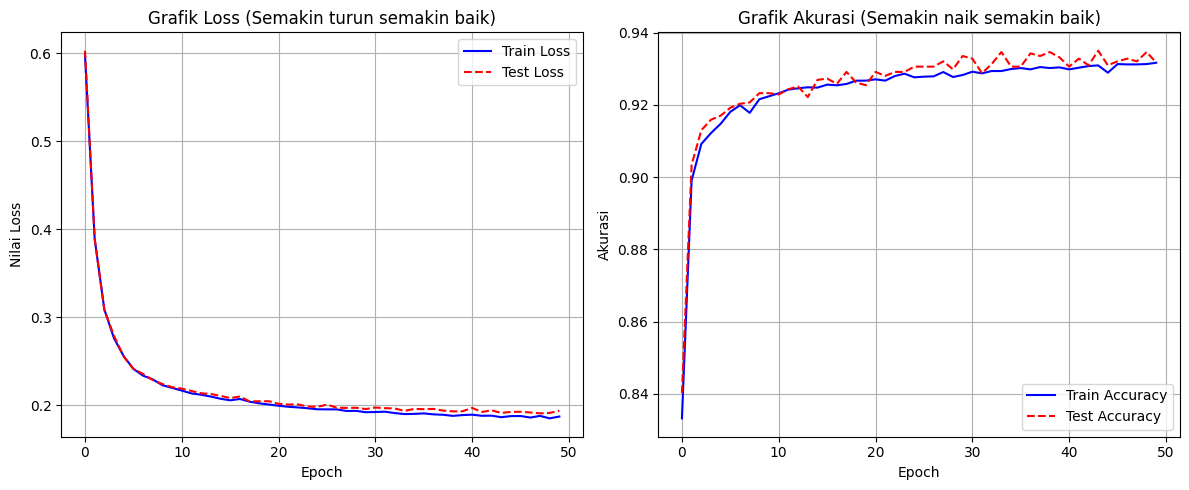

In [14]:
import matplotlib.pyplot as plt

print("1. Menyiapkan arsitektur model ANN manual...")
input_size = X_train.shape[1]
hidden_layers = [32, 16]
output_size = y_train.shape[1]

model_manual = NeuralNetwork(
    input_size=input_size, 
    hidden_layers=hidden_layers, 
    output_size=output_size, 
    activation_name="relu", 
    init_method="he", 
    learning_rate=0.01
)

print("\n2. Memulai proses belajar (Training)...")
history_manual = train_model(
    model_manual, 
    X_train, y_train, 
    X_test, y_test, 
    epochs=50, 
    batch_size=32
)

print("\n3. Menggambar grafik evaluasi pembelajaran...")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_manual['train_loss'], label='Train Loss', color='blue')
plt.plot(history_manual['test_loss'], label='Test Loss', color='red', linestyle='dashed')
plt.title('Grafik Loss (Semakin turun semakin baik)')
plt.xlabel('Epoch')
plt.ylabel('Nilai Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_manual['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history_manual['test_acc'], label='Test Accuracy', color='red', linestyle='dashed')
plt.title('Grafik Akurasi (Semakin naik semakin baik)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1. Membangun arsitektur model Keras...
2. Kompilasi model...
3. Memulai proses training Keras...
Epoch 1/50


c:\laragon\www\Tugas_Besar_ANN\env_tugas_ann\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6548 - loss: 1.0077 - val_accuracy: 0.8164 - val_loss: 0.6463
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 0.5044 - val_accuracy: 0.8836 - val_loss: 0.4122
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8914 - loss: 0.3676 - val_accuracy: 0.9038 - val_loss: 0.3280
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9037 - loss: 0.3104 - val_accuracy: 0.9086 - val_loss: 0.2873
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9084 - loss: 0.2791 - val_accuracy: 0.9100 - val_loss: 0.2673
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9116 - loss: 0.2601 - val_accuracy: 0.9130 - val_loss: 0.2507
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9151 - loss: 0.2474 - val_accuracy: 0.9155 - val_loss: 0.2428
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9176 - loss: 0.2382 - val_accuracy: 0.9174 - val_

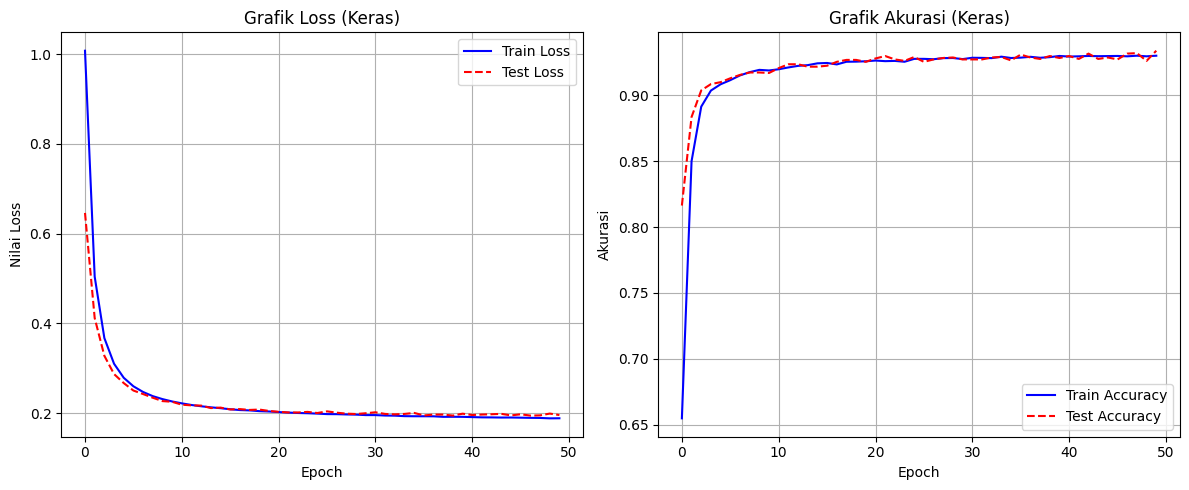

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("1. Membangun arsitektur model Keras...")
model_keras = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],), kernel_initializer='he_normal'),
    Dense(16, activation='relu', kernel_initializer='he_normal'),
    Dense(y_train.shape[1], activation='softmax')
])

print("2. Kompilasi model...")
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model_keras.compile(optimizer=optimizer, 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

print("3. Memulai proses training Keras...")
history_keras = model_keras.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

print("\n4. Menggambar grafik evaluasi pembelajaran Keras...")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_keras.history['loss'], label='Train Loss', color='blue')
plt.plot(history_keras.history['val_loss'], label='Test Loss', color='red', linestyle='dashed')
plt.title('Grafik Loss (Keras)')
plt.xlabel('Epoch')
plt.ylabel('Nilai Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_keras.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_keras.history['val_accuracy'], label='Test Accuracy', color='red', linestyle='dashed')
plt.title('Grafik Akurasi (Keras)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Eksperimen all in sedang berjalan...
1/4 Menguji Fungsi Aktivasi (ReLU, Sigmoid, Tanh)...
2/4 Menguji Learning Rate (0.1, 0.01, 0.001)...
3/4 Menguji Inisialisasi Bobot...
4/4 Membuat Confusion Matrix...


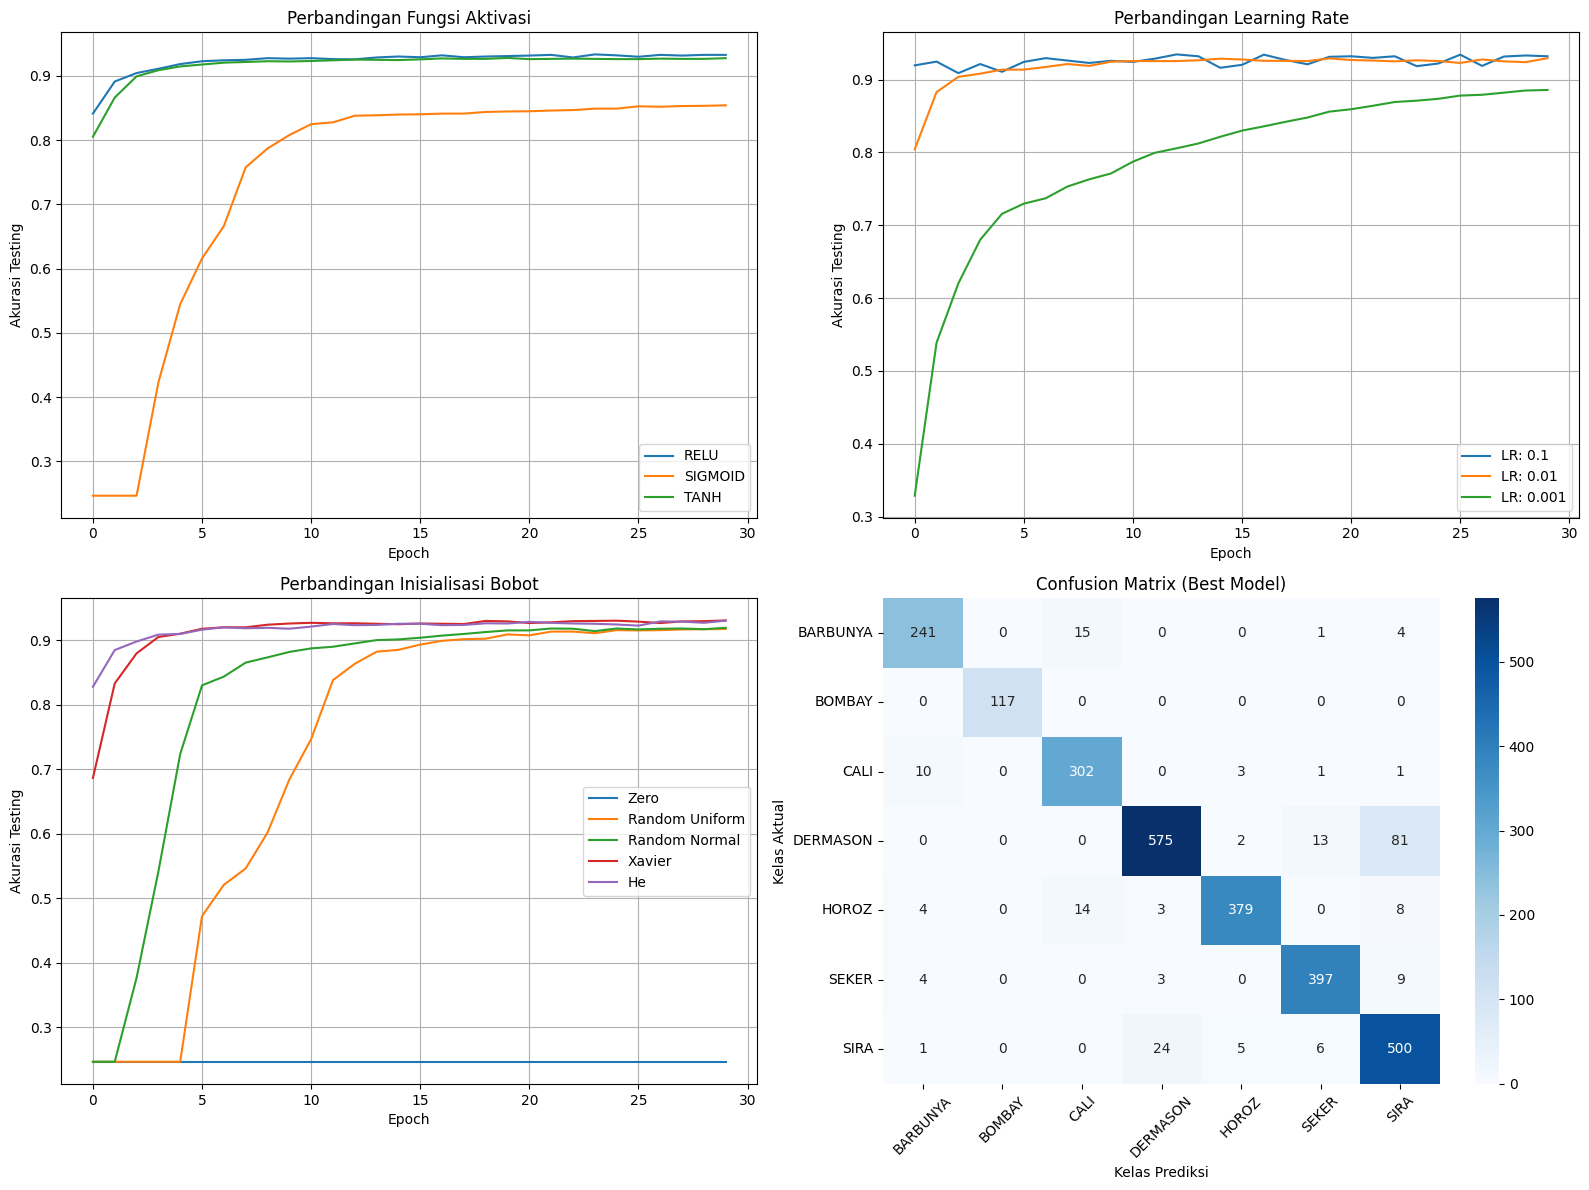


Seluruh Eksperimen Selesai!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

class DenseLayer:
    def __init__(self, input_size, output_size, init_method="he"):
        self.input_size = input_size
        self.output_size = output_size
        self.init_method = init_method
        self.weights, self.bias = self._initialize_weights()

    def _initialize_weights(self):
        bias = np.zeros((1, self.output_size))
        if self.init_method == "zero":
            weights = np.zeros((self.input_size, self.output_size))
        elif self.init_method == "random_uniform":
            weights = np.random.uniform(-0.05, 0.05, (self.input_size, self.output_size))
        elif self.init_method == "random_normal":
            weights = np.random.randn(self.input_size, self.output_size) * 0.05
        elif self.init_method == "xavier":
            limit = np.sqrt(6.0 / (self.input_size + self.output_size))
            weights = np.random.uniform(-limit, limit, (self.input_size, self.output_size))
        else: # Default: He
            weights = np.random.randn(self.input_size, self.output_size) * np.sqrt(2.0 / self.input_size)
        return weights, bias

class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, output_size, activation_name="relu", init_method="he", learning_rate=0.01):
        self.layers = []
        self.activation_name = activation_name
        self.learning_rate = learning_rate
        layer_sizes = [input_size] + hidden_layers + [output_size]
        for i in range(len(layer_sizes) - 1):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i+1], init_method=init_method))
            
    def forward(self, X):
        self.a_values = [X]
        self.z_values = []
        A = X
        for i, layer in enumerate(self.layers):
            Z = np.dot(A, layer.weights) + layer.bias
            self.z_values.append(Z)
            if i == len(self.layers) - 1:
                A = Activation.softmax(Z)
            else:
                if self.activation_name == "relu": A = Activation.relu(Z)
                elif self.activation_name == "sigmoid": A = Activation.sigmoid(Z)
                elif self.activation_name == "tanh": A = Activation.tanh(Z)
            self.a_values.append(A)
        return A

    def backward(self, y_true):
        samples = y_true.shape[0]
        self.d_weights = []
        self.d_biases = []
        dZ = self.a_values[-1] - y_true 
        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            A_prev = self.a_values[i]
            self.d_weights.insert(0, np.dot(A_prev.T, dZ) / samples)
            self.d_biases.insert(0, np.sum(dZ, axis=0, keepdims=True) / samples)
            if i > 0: 
                dA_prev = np.dot(dZ, layer.weights.T)
                Z_prev = self.z_values[i-1] 
                if self.activation_name == "relu": dZ = dA_prev * Activation.relu_derivative(Z_prev)
                elif self.activation_name == "sigmoid": dZ = dA_prev * Activation.sigmoid_derivative(Z_prev)
                elif self.activation_name == "tanh": dZ = dA_prev * Activation.tanh_derivative(Z_prev)
                    
    def update_weights(self):
        for i in range(len(self.layers)):
            self.layers[i].weights -= self.learning_rate * self.d_weights[i]
            self.layers[i].bias -= self.learning_rate * self.d_biases[i]

def silent_train(model, epochs=30, batch_size=32):
    history = []
    n_samples = X_train.shape[0]
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_train_shuffled, y_train_shuffled = X_train[indices], y_train[indices]
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            model.forward(X_train_shuffled[start_idx:end_idx])
            model.backward(y_train_shuffled[start_idx:end_idx])
            model.update_weights()
        y_test_pred = model.forward(X_test)
        acc = np.mean(np.argmax(y_test_pred, axis=1) == np.argmax(y_test, axis=1))
        history.append(acc)
    return history

print("Eksperimen all in sedang berjalan...")
epochs_exp = 30 # Menggunakan 30 epoch per tes agar laptop tidak kepanasan

print("1/4 Menguji Fungsi Aktivasi (ReLU, Sigmoid, Tanh)...")
activations = ["relu", "sigmoid", "tanh"]
act_results = {}
for act in activations:
    model = NeuralNetwork(X_train.shape[1], [32, 16], y_train.shape[1], activation_name=act, init_method="he", learning_rate=0.01)
    act_results[act] = silent_train(model, epochs=epochs_exp)

print("2/4 Menguji Learning Rate (0.1, 0.01, 0.001)...")
lrs = [0.1, 0.01, 0.001]
lr_results = {}
for lr in lrs:
    model = NeuralNetwork(X_train.shape[1], [32, 16], y_train.shape[1], activation_name="relu", init_method="he", learning_rate=lr)
    lr_results[str(lr)] = silent_train(model, epochs=epochs_exp)

print("3/4 Menguji Inisialisasi Bobot...")
inits = ["zero", "random_uniform", "random_normal", "xavier", "he"]
init_results = {}
for init in inits:
    model = NeuralNetwork(X_train.shape[1], [32, 16], y_train.shape[1], activation_name="relu", init_method=init, learning_rate=0.01)
    init_results[init] = silent_train(model, epochs=epochs_exp)

print("4/4 Membuat Confusion Matrix...")
# Menggunakan model terbaik sebagai contoh
best_model = NeuralNetwork(X_train.shape[1], [32, 16], y_train.shape[1], activation_name="relu", init_method="he", learning_rate=0.1)
silent_train(best_model, epochs=50) # Train penuh
y_test_pred = best_model.forward(X_test)
cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_test_pred, axis=1))

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
for act, hist in act_results.items(): plt.plot(hist, label=act.upper())
plt.title("Perbandingan Fungsi Aktivasi")
plt.xlabel("Epoch"); plt.ylabel("Akurasi Testing")
plt.legend(); plt.grid(True)

plt.subplot(2, 2, 2)
for lr, hist in lr_results.items(): plt.plot(hist, label=f"LR: {lr}")
plt.title("Perbandingan Learning Rate")
plt.xlabel("Epoch"); plt.ylabel("Akurasi Testing")
plt.legend(); plt.grid(True)

plt.subplot(2, 2, 3)
for init, hist in init_results.items(): plt.plot(hist, label=init.replace('_', ' ').title())
plt.title("Perbandingan Inisialisasi Bobot")
plt.xlabel("Epoch"); plt.ylabel("Akurasi Testing")
plt.legend(); plt.grid(True)

plt.subplot(2, 2, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Kelas Prediksi"); plt.ylabel("Kelas Aktual")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("\nSeluruh Eksperimen Selesai!")

 Eksperimen tahap akhir menguji 200 Epoch sedang berjalan......)
1/3 Menguji Arsitektur Jaringan...
2/3 Menguji Batch Size (16, 32, 64)...
3/3 Menguji Overfitting pada 200 Epoch...


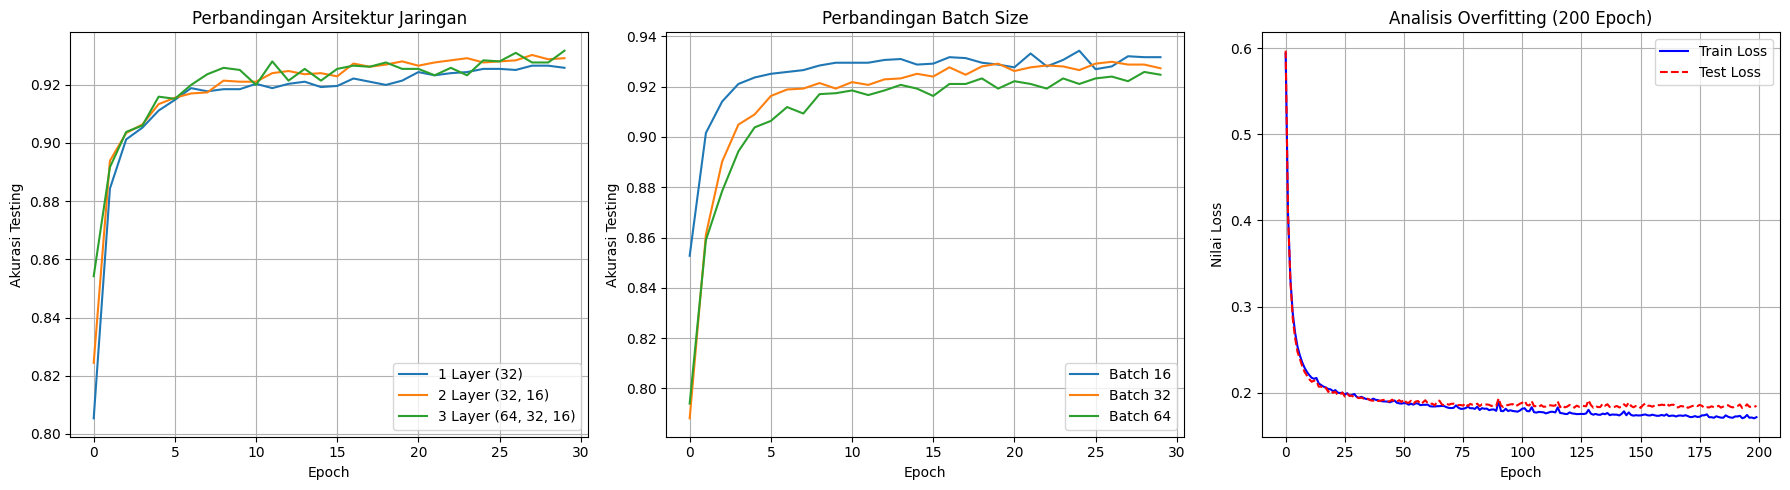


uji telah berhasil!


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def calculate_loss(y_true, y_pred):
    samples = y_true.shape[0]
    y_pred_clipped = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.sum(y_true * np.log(y_pred_clipped)) / samples

def train_for_overfitting(model, epochs=50, batch_size=32):
    train_losses, test_losses = [], []
    n_samples = X_train.shape[0]
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_train_shuffled, y_train_shuffled = X_train[indices], y_train[indices]
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            model.forward(X_train_shuffled[start_idx:end_idx])
            model.backward(y_train_shuffled[start_idx:end_idx])
            model.update_weights()
            
        # Catat loss tiap epoch menggunakan fungsi bantuan
        y_train_pred = model.forward(X_train)
        y_test_pred = model.forward(X_test)
        train_losses.append(calculate_loss(y_train, y_train_pred))
        test_losses.append(calculate_loss(y_test, y_test_pred))
    return train_losses, test_losses

print(" Eksperimen tahap akhir menguji 200 Epoch sedang berjalan......)")

print("1/3 Menguji Arsitektur Jaringan...")
architectures = {"1 Layer (32)": [32], "2 Layer (32, 16)": [32, 16], "3 Layer (64, 32, 16)": [64, 32, 16]}
arch_results = {}
for name, layers in architectures.items():
    model = NeuralNetwork(X_train.shape[1], layers, y_train.shape[1], activation_name="relu")
    arch_results[name] = silent_train(model, epochs=30)

print("2/3 Menguji Batch Size (16, 32, 64)...")
batch_sizes = [16, 32, 64]
batch_results = {}
for bs in batch_sizes:
    model = NeuralNetwork(X_train.shape[1], [32, 16], y_train.shape[1], activation_name="relu")
    batch_results[f"Batch {bs}"] = silent_train(model, epochs=30, batch_size=bs)

print("3/3 Menguji Overfitting pada 200 Epoch...")
model_epoch = NeuralNetwork(X_train.shape[1], [32, 16], y_train.shape[1], activation_name="relu")
train_losses, test_losses = train_for_overfitting(model_epoch, epochs=200, batch_size=32)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
for name, hist in arch_results.items(): plt.plot(hist, label=name)
plt.title("Perbandingan Arsitektur Jaringan")
plt.xlabel("Epoch"); plt.ylabel("Akurasi Testing")
plt.legend(); plt.grid(True)

plt.subplot(1, 3, 2)
for name, hist in batch_results.items(): plt.plot(hist, label=name)
plt.title("Perbandingan Batch Size")
plt.xlabel("Epoch"); plt.ylabel("Akurasi Testing")
plt.legend(); plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(test_losses, label="Test Loss", color='red', linestyle='dashed')
plt.title("Analisis Overfitting (200 Epoch)")
plt.xlabel("Epoch"); plt.ylabel("Nilai Loss")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()
print("\nuji telah berhasil!")

In [11]:
from sklearn.neural_network import MLPClassifier
print("Training dengan Sklearn sukses!")
model_sklearn = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', max_iter=50, random_state=42)
model_sklearn.fit(X_train, np.argmax(y_train, axis=1))
print(f"Akurasi Sklearn: {model_sklearn.score(X_test, np.argmax(y_test, axis=1)):.4f}")

Training dengan Sklearn sukses!
Akurasi Sklearn: 0.9324


c:\laragon\www\Tugas_Besar_ANN\env_tugas_ann\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


## Kesimpulan Tugas Besar ANN

Berdasarkan eksperimen klasifikasi *Dry Bean Dataset* yang telah dilakukan, dapat ditarik beberapa kesimpulan:

1. Perbandingan Akurasi: Model ANN manual yang dibangun dari awal (from scratch) mendapatkan akurasi testing sebesar 92.95% pada epoch 50 dengan nilai loss 0.1969. Sementara itu, model yang menggunakan Keras mendapatkan akurasi testing sebesar 93.02% dengan nilai loss 0.1958. Hal ini menunjukkan bahwa model manual yang dirancang beroperasi dengan sangat akurat dan performanya terbukti setara dengan framework standar industri.
2. Proses Training (Grafik Loss): DDari grafik perbandingan Loss dan Accuracy, terlihat bahwa model manual mengalami sedikit fluktuasi (garis grafik sedikit bergetar) pada setiap epoch-nya, meskipun tren utamanya berhasil menurun dan naik dengan sangat baik. Di sisi lain, model Keras menampilkan kurva yang jauh lebih mulus, stabil, dan konsisten, yang menunjukkan adanya optimasi perhitungan tingkat lanjut pada backend TensorFlow. Kedua model juga menunjukkan kecocokan yang ketat antara data train dan test, menandakan tidak terjadinya overfitting.
3. Kompleksitas Kode: Membangun ANN dari awal membutuhkan pemahaman mendalam tentang kalkulus (terutama untuk kalkulasi turunan pada Backpropagation) dan aljabar linear. Penulisan kodenya juga sangat panjang dan lebih rentan terhadap error matriks. Sebaliknya, penggunaan framework modern seperti Keras membuat proses perancangan arsitektur jaringan jauh lebih ringkas, rapi, dan efisien untuk diimplementasikan pada kasus nyata.